        Date  Consumption  Wind  Solar  Wind+Solar
0 2006-01-01     1069.184   NaN    NaN         NaN
1 2006-01-02     1380.521   NaN    NaN         NaN
2 2006-01-03     1442.533   NaN    NaN         NaN
3 2006-01-04     1457.217   NaN    NaN         NaN
4 2006-01-05     1477.131   NaN    NaN         NaN
                      Date  Consumption         Wind        Solar   Wind+Solar
count                 4383  4383.000000  2920.000000  2188.000000  2187.000000
mean   2012-01-01 00:00:00  1338.675836   164.814173    89.258695   272.663481
min    2006-01-01 00:00:00   842.395000     5.757000     1.968000    21.478000
25%    2008-12-31 12:00:00  1217.859000    62.353250    35.179250   172.185500
50%    2012-01-01 00:00:00  1367.123000   119.098000    86.407000   240.991000
75%    2014-12-31 12:00:00  1457.761000   217.900250   135.071500   338.988000
max    2017-12-31 00:00:00  1709.568000   826.278000   241.580000   851.556000
std                    NaN   165.775710   143.692732    58.550

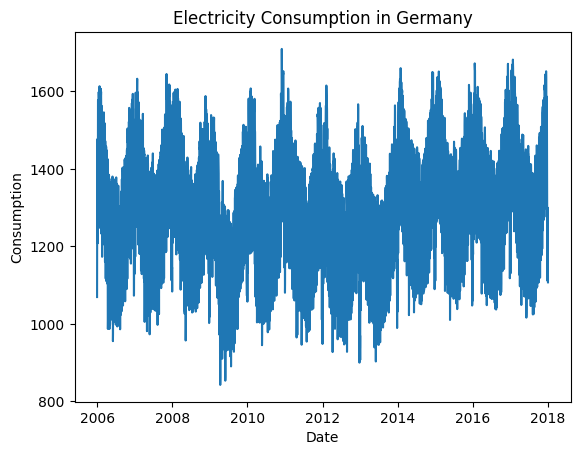

             Consumption      Wind     Solar
Consumption     1.000000  0.136821 -0.278943
Wind            0.136821  1.000000 -0.308832
Solar          -0.278943 -0.308832  1.000000


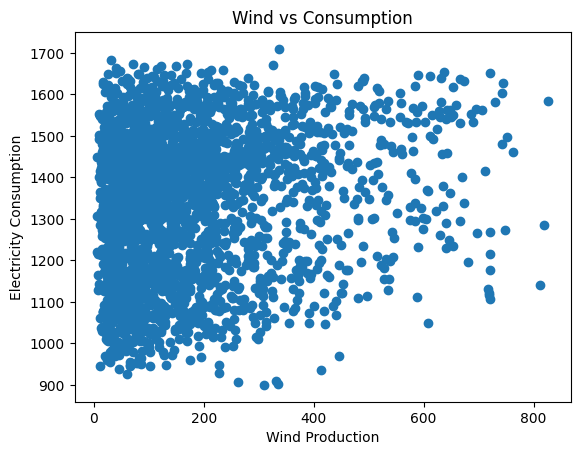

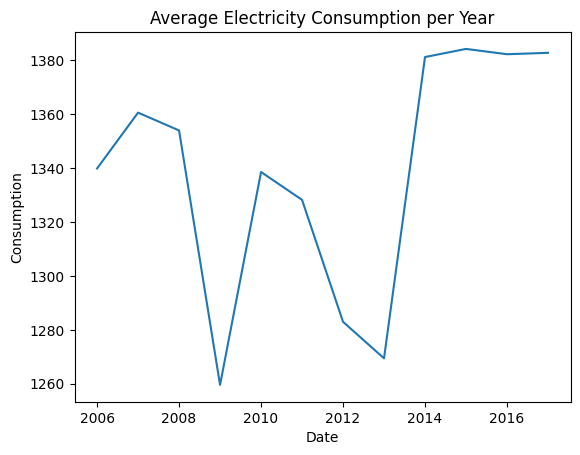

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Daten laden
url = "https://raw.githubusercontent.com/jenfly/opsd/master/opsd_germany_daily.csv"
df = pd.read_csv(url)

# Datum konvertieren
df["Date"] = pd.to_datetime(df["Date"])

# Überblick über die Daten
print(df.head())
print(df.describe())

# NaN entfernen
data = df[["Wind", "Solar", "Consumption"]].dropna()

X = data[["Wind", "Solar"]]
y = data["Consumption"]

model = LinearRegression()
model.fit(X, y)

print("Model coefficients:", model.coef_)

# Zeitreihe plotten
plt.figure()
plt.plot(df["Date"], df["Consumption"])
plt.title("Electricity Consumption in Germany")
plt.xlabel("Date")
plt.ylabel("Consumption")
plt.show()

# Korrelation analysieren
corr = df[["Consumption", "Wind", "Solar"]].corr()
print(corr)

# Scatterplot
plt.figure()
plt.scatter(df["Wind"], df["Consumption"])
plt.xlabel("Wind Production")
plt.ylabel("Electricity Consumption")
plt.title("Wind vs Consumption")
plt.show()


#Plot of Average Electricity Consumption per year
plt.figure()
df.groupby(df["Date"].dt.year)["Consumption"].mean().plot()
plt.title("Average Electricity Consumption per Year")
plt.ylabel("Consumption")
plt.show()